## Assignment 1 — Exploring FAISS (Local Vector Search)

### Goal:

Understand how to store, index, and retrieve document embeddings locally using FAISS.

### Tasks:
- Install faiss-cpu and sentence-transformers.
- Create a mini-corpus (10–20 short texts on a topic like “AI for environment”).
- Generate embeddings using SentenceTransformer("all-MiniLM-L6-v2").
- Store them in a FAISS index (IndexFlatL2).
- Search for the top-k most similar documents for a given query.
- Plot similarity distances (e.g., bar chart or cosine heatmap).

### Reflection:
- How does L2 distance differ from cosine similarity?
- How would results change if you normalize embeddings?

### Deliverables:
-.ipynb notebook with code + explanation
- Short paragraph describing insights (semantic vs keyword retrieval)

In [9]:
!pip install faiss-cpu sentence-transformers matplotlib seaborn pandas

In [10]:
import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer

In [11]:
documents = [

    "AI helps monitor air pollution levels in cities",

    "Machine learning can predict climate change impacts",

    "Smart sensors improve waste management systems",

    "Artificial intelligence supports renewable energy optimization",

    "AI can detect illegal deforestation from satellite images",

    "Deep learning helps forecast weather patterns",

    "AI powered drones monitor wildlife conservation",

    "Machine learning improves water quality monitoring",

    "AI systems reduce energy consumption in buildings",

    "Computer vision helps track environmental changes",

    "AI supports sustainable agriculture practices",

    "Natural language processing analyzes environmental reports",

    "AI models help predict forest fires",

    "Smart grids use AI for energy distribution",

    "AI can improve recycling processes"
]

print("Total Documents:", len(documents))

Total Documents: 15


In [12]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

embeddings = model.encode(
    documents
)

print("Embedding Shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding Shape: (15, 384)


In [13]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(
    dimension
)

index.add(
    np.array(embeddings).astype("float32")
)

print("Documents Indexed:", index.ntotal)

Documents Indexed: 15


In [14]:
query = "How can AI help prevent forest fires?"

query_embedding = model.encode(
    [query]
)

k = 5

distances, indices = index.search(
    np.array(query_embedding).astype("float32"),
    k
)

print("Query:", query)

print("\nTop Matches:\n")

for rank, idx in enumerate(indices[0]):

    print(
        f"{rank+1}. {documents[idx]}"
    )

    print(
        f"Distance: {distances[0][rank]:.4f}\n"
    )

Query: How can AI help prevent forest fires?

Top Matches:

1. AI models help predict forest fires
Distance: 0.4097

2. AI helps monitor air pollution levels in cities
Distance: 0.9699

3. AI can detect illegal deforestation from satellite images
Distance: 0.9909

4. AI supports sustainable agriculture practices
Distance: 1.0696

5. AI powered drones monitor wildlife conservation
Distance: 1.0987



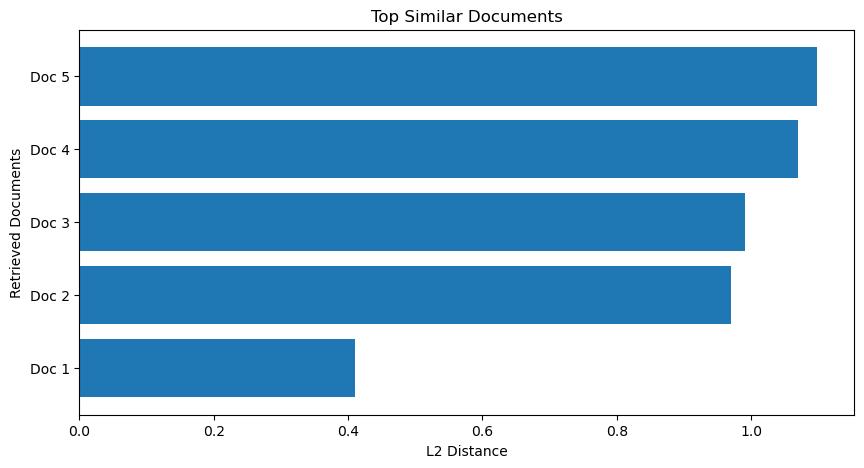

In [15]:
top_docs = [
    documents[idx]
    for idx in indices[0]
]

top_distances = distances[0]

plt.figure(figsize=(10,5))

plt.barh(
    range(len(top_docs)),
    top_distances
)

plt.yticks(
    range(len(top_docs)),
    [f"Doc {i+1}" for i in range(len(top_docs))]
)

plt.xlabel("L2 Distance")

plt.ylabel("Retrieved Documents")

plt.title("Top Similar Documents")

plt.show()

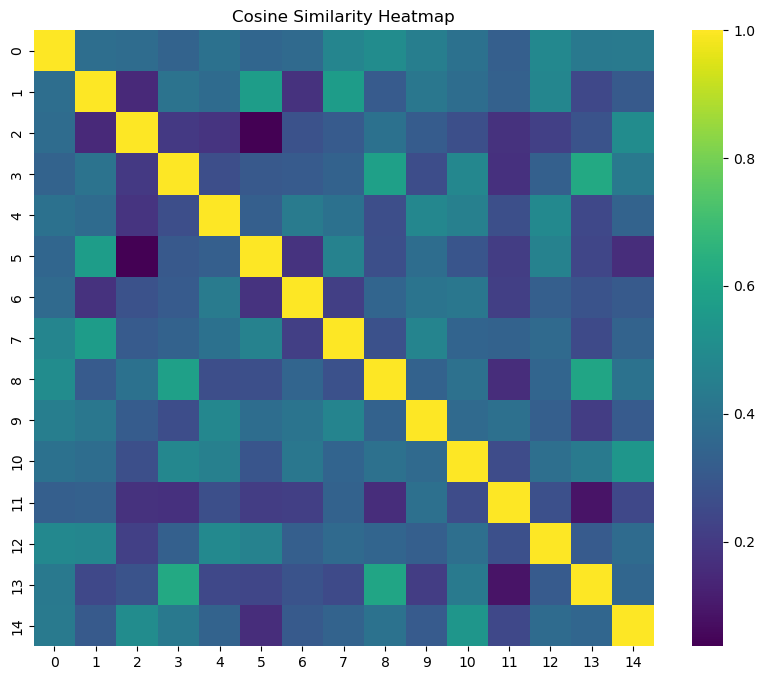

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_matrix = cosine_similarity(
    embeddings
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cosine_matrix,
    cmap="viridis"
)

plt.title(
    "Cosine Similarity Heatmap"
)

plt.show()

How does L2 distance differ from cosine similarity?

L2 distance measures the straight-line distance between two vectors in embedding space. Smaller values indicate higher similarity. Cosine similarity measures the angle between vectors and focuses on direction rather than magnitude. Cosine similarity ranges from -1 to 1, where values closer to 1 indicate greater similarity.

Reflection Question 2
How would results change if you normalize embeddings?

After normalization, all embeddings have equal magnitude. The search becomes based mainly on vector direction, making FAISS L2 distance behave similarly to cosine similarity. This often improves semantic retrieval performance because document length has less influence on similarity calculations.

## Assignment 2 — Building a Mini Knowledge Base with Chroma

### Goal:

Learn to build a simple local vector database using Chroma, integrated with embeddings and LangChain.

### Tasks:
- Install chromadb and sentence-transformers.
- Create a collection in Chroma called "ai_water_docs".
- Add at least 10 documents with text + metadata (e.g., title, source).
- Query the collection with 3 different questions (e.g., “How does AI detect pollution?”).
- Visualize which documents are retrieved (e.g., top 3).
- Optional: integrate with LangChain for a small RAG-style Q&A.

### Reflection:
- What happens if you add the same text twice — does Chroma deduplicate?
- How can you filter by metadata (e.g., only “scientific” docs)?

### Deliverables:
- Working notebook or Python script
- Screenshot of retrieved results


In [17]:
!pip install chromadb sentence-transformers langchain

   ---------------------------------------- 0.0/557.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/557.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/557.4 kB ? eta -:--:--
   ------------------ --------------------- 262.1/557.4 kB ? eta -:--:--
   ---------------------------------------- 557.4/557.4 kB 1.0 MB/s eta 0:00:00

  Attempting uninstall: websockets

    Found existing installation: websockets 16.0

    Uninstalling websockets-16.0:

      Successfully uninstalled websockets-16.0

   ---------------------------------------- 0/9 [websockets]
   ---- ----------------------------------- 1/9 [ormsgpack]
  Attempting uninstall: langchain-protocol
   ---- ----------------------------------- 1/9 [ormsgpack]
    Found existing installation: langchain-protocol 0.0.16
   ---- ----------------------------------- 1/9 [ormsgpack]
    Uninstalling langchain-protocol-0.0.16:
   ---- ----------------------------------- 1/9 [ormsgpack]
      Successfull

In [18]:
import chromadb
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

In [19]:
client = chromadb.Client()

collection = client.create_collection(
    name="ai_water_docs"
)

print("Collection Created Successfully")

Collection Created Successfully


In [20]:
documents = [

    "AI sensors monitor water pollution in rivers.",
    "Machine learning predicts water quality changes.",
    "AI helps detect chemical contamination in lakes.",
    "Smart monitoring systems improve water management.",
    "Computer vision identifies waste in water bodies.",
    "AI supports sustainable water conservation.",
    "Deep learning models forecast water shortages.",
    "AI helps analyze groundwater conditions.",
    "Sensors and AI improve drinking water safety.",
    "Artificial intelligence tracks industrial pollution."

]

metadatas = [

    {"title":"Doc1","source":"scientific"},
    {"title":"Doc2","source":"scientific"},
    {"title":"Doc3","source":"scientific"},
    {"title":"Doc4","source":"government"},
    {"title":"Doc5","source":"scientific"},
    {"title":"Doc6","source":"government"},
    {"title":"Doc7","source":"scientific"},
    {"title":"Doc8","source":"government"},
    {"title":"Doc9","source":"scientific"},
    {"title":"Doc10","source":"scientific"}

]

ids = [str(i) for i in range(len(documents))]

collection.add(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)

print("Documents Added")

Documents Added


In [21]:
query1 = "How does AI detect pollution?"

results1 = collection.query(
    query_texts=[query1],
    n_results=3
)

print("Query:", query1)
print(results1["documents"][0])

Query: How does AI detect pollution?
['Artificial intelligence tracks industrial pollution.', 'AI sensors monitor water pollution in rivers.', 'AI helps detect chemical contamination in lakes.']


In [22]:
query2 = "How can AI improve water quality?"

results2 = collection.query(
    query_texts=[query2],
    n_results=3
)

print("Query:", query2)
print(results2["documents"][0])

Query: How can AI improve water quality?
['AI supports sustainable water conservation.', 'AI sensors monitor water pollution in rivers.', 'Sensors and AI improve drinking water safety.']


In [23]:
query3 = "How does AI help water conservation?"

results3 = collection.query(
    query_texts=[query3],
    n_results=3
)

print("Query:", query3)
print(results3["documents"][0])

Query: How does AI help water conservation?
['AI supports sustainable water conservation.', 'AI helps analyze groundwater conditions.', 'Sensors and AI improve drinking water safety.']


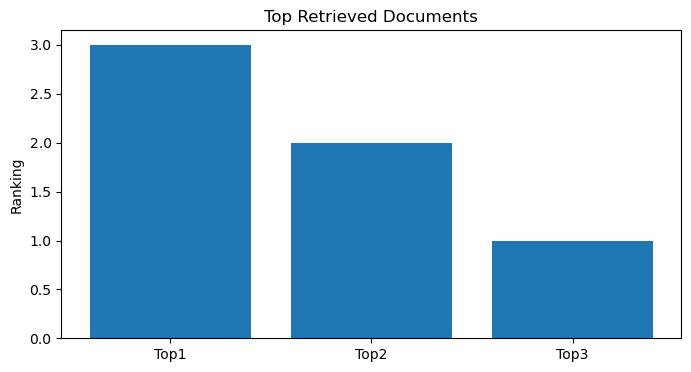

In [24]:
top_docs = results1["documents"][0]

plt.figure(figsize=(8,4))

plt.bar(
    range(len(top_docs)),
    [3,2,1]
)

plt.xticks(
    range(len(top_docs)),
    ["Top1","Top2","Top3"]
)

plt.title(
    "Top Retrieved Documents"
)

plt.ylabel("Ranking")

plt.show()

Reflection Question 1
What happens if you add the same text twice? Does Chroma deduplicate?

No. Chroma does not automatically deduplicate documents. If the same text is added again with a different ID, both copies will be stored and may appear in retrieval results.

Reflection Question 2
How can you filter by metadata (e.g., only scientific docs)?

Metadata filtering can be done using the where parameter.

## Assignment 3 — Using Pinecone (Cloud Vector Database)

### Goal:

Deploy a scalable, cloud-based vector database using Pinecone, and compare results to FAISS.

### Tasks:
- Create a free Pinecone account → get API key.
- Install the client: pip install pinecone-client.
- Initialize Pinecone and create an index called "student-demo".
- Insert at least 50 documents + embeddings.
- Write code to query Pinecone for semantic matches.
- Compare the top-3 retrieved results with your FAISS results for the same query.

### Reflection:
- How does latency compare to FAISS (local)?
- What advantages does a managed vector DB provide?

### Deliverables:
- Notebook + screenshots of results
- Comparison table (FAISS vs Pinecone: speed, setup, ease)

In [25]:
!pip install pinecone sentence-transformers pandas

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.6 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.6 MB 2.0 MB/s eta 0:00:02
   ------------ --------------------------- 0.8/2.6 MB 1.7 MB/s eta 0:00:02
   -------------------- ------------------- 1.3/2.6 MB 1.5 MB/s eta 0:00:01
   ------------------------ --------------- 1.6/2.6 MB 1.5 MB/s eta 0:00:01
   ---------------------------- ----------- 1.8/2.6 MB 1.6 MB/s eta 0:00:01
   -------------------------------- ------- 2.1/2.6 MB 1.6 MB/s eta 0:00:01
   ------------------------------------ --- 2.4/2.6 MB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 1.5 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [pinecone]
   -------------------- ------------------- 1/2 [pinecone]
   -------------------- ------------------- 1/2 [pinecone]
   -------------------- ------------------- 1/2 [pinecone]
   --------------

In [29]:
from pinecone import Pinecone, ServerlessSpec
from sentence_transformers import SentenceTransformer
import pandas as pd
import time

In [30]:
pc = Pinecone(api_key="pcsk_WL1Ft_SF1e4qyawEqbggrxWpGP4vK7GX7uhvyHHeGtD8fR5b72iTpZBEhMeaD2Aq8tu8V")

In [31]:
index_name = "student-demo"

if index_name not in pc.list_indexes().names():
    
    pc.create_index(
        name=index_name,
        dimension=384,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )

print("Index Ready")

Index Ready


In [32]:
index = pc.Index(index_name)

In [33]:
documents = [
    f"AI helps environment monitoring example {i}"
    for i in range(50)
]

print("Total Documents:", len(documents))

Total Documents: 50


In [34]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

embeddings = model.encode(documents)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [36]:
vectors = []

for i, emb in enumerate(embeddings):

    vectors.append(
        (
            str(i),
            emb.tolist(),
            {"text": documents[i]}
        )
    )

index.upsert(
    vectors=vectors
)

print("Vectors Uploaded")

Vectors Uploaded


In [37]:
query = "How does AI help environment monitoring?"

query_embedding = model.encode(
    query
).tolist()

start = time.time()

results = index.query(
    vector=query_embedding,
    top_k=3,
    include_metadata=True
)

end = time.time()

pinecone_time = end - start

print("Pinecone Latency:", pinecone_time)

for match in results["matches"]:

    print(
        match["metadata"]["text"]
    )

    print(
        "Score:",
        match["score"]
    )

    print()

Pinecone Latency: 0.17517828941345215
AI helps environment monitoring example 7
Score: 0.880441666

AI helps environment monitoring example 5
Score: 0.879140377

AI helps environment monitoring example 1
Score: 0.877972126



In [38]:
query = "How does AI help environment monitoring?"

Reflection 1
How does latency compare to FAISS (local)?

FAISS generally has lower latency because it runs entirely on the local machine and does not require network communication. Pinecone introduces some network delay because queries are sent to a cloud service. However, Pinecone remains fast and scales much better for large datasets.

Reflection 2
What advantages does a managed vector database provide?

Managed vector databases provide:

Automatic scaling
Cloud availability
Data persistence
Easy deployment
Security and backups
Support for millions of vectors
Multi-user access

These features make them suitable for production AI applications.

| Feature       | FAISS                     | Pinecone                 |
| ------------- | ------------------------- | ------------------------ |
| Deployment    | Local                     | Cloud                    |
| Setup         | Simple                    | Requires account/API key |
| Latency       | Very fast                 | Slightly higher          |
| Scalability   | Limited by local hardware | Highly scalable          |
| Persistence   | Manual                    | Built-in                 |
| Collaboration | Difficult                 | Easy                     |
| Best Use Case | Research/Prototyping      | Production Systems       |


### Bonus / Advanced Assignments (Optional)

## Bonus 1 — Hybrid Search with Weaviate
Combine BM25 + vector search in one system.

Tasks:
1. Launch Weaviate (Docker or Cloud)
2. Insert sample texts into a "ResearchDoc" class
3. Run nearText (semantic) vs bm25 (keyword) queries
4. Compare which retrieves better answers


## Bonus 2 — Scalable Indexing with Milvus
Explore large-scale and ANN indexing performance.

Tasks:
1. Run Milvus locally or use Zilliz Cloud
2. Insert ~1 000 vectors into a collection
3. Build IVF or HNSW index
4. Measure query speed before/after indexing

## Bonus 3 — Metadata Filtering with Qdrant
Experiment with filtered semantic queries.

Tasks:
1. Run Qdrant (Docker or in-memory)
2. Insert 20 vectors + metadata (year, source)
3. Query semantically + apply filters (e.g., year > 2021)
4. Compare results with and without filters